env: OMP_NUM_THREADS=1


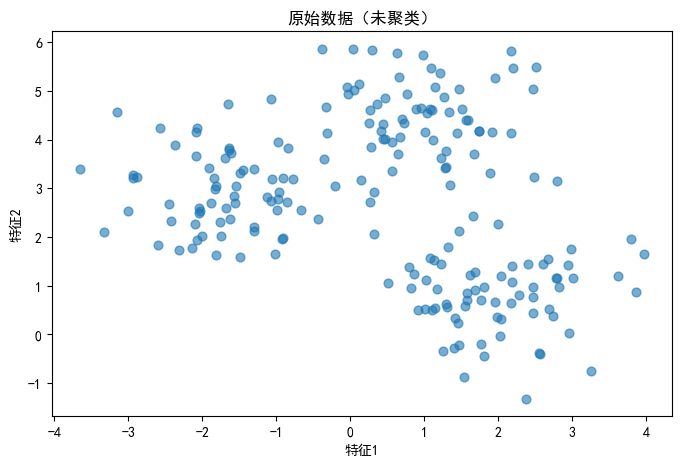

In [8]:
%set_env OMP_NUM_THREADS=1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

plt.rcParams['font.sans-serif']=['Micosoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False

X,y=make_blobs(n_samples=200,centers=3,cluster_std=0.8,random_state=0)

plt.figure(figsize=(8,5))
plt.scatter(X[:,0],X[:,1],s=40,alpha=0.6)
plt.title('原始数据（未聚类）')
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.show()

In [9]:
from sklearn.metrics.pairwise import euclidean_distances

initial_centers=X[[0,50,100]]
print("初始簇中心（随机选择）:")
for i,c in enumerate(initial_centers):
    print(f"  中心{i+1}: {c}")

distances = euclidean_distances(X, initial_centers)
labels = np.argmin(distances,axis=1)

new_centers=[]
for i in range(3):
    cluster_points = X[labels == i]
    new_center = cluster_points.mean(axis=0)
    new_centers.append(new_center)

print("\n更新后的簇中心:")
for i,c in enumerate(new_centers):
    print(f"  中心{i+1}:{c}")

初始簇中心（随机选择）:
  中心1: [-1.69242695  3.62202539]
  中心2: [0.4688124  4.01359439]
  中心3: [ 1.77207239 -0.20229737]

更新后的簇中心:
  中心1:[-1.7509069   2.91518593]
  中心2:[0.97530727 4.29223131]
  中心3:[1.9950264 0.7218253]


In [10]:
kmeans = KMeans(n_clusters=3,random_state=42)

kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_
inertia = kmeans.inertia_

print("="*40)
print("K均值聚类结果")
print("="*40)
print(f"簇中心:\n{centers}")
print(f"\n惯性（簇内紧密程度）:{inertia:.2f}")
print(f"\n各簇大小：{np.bincount(labels)}")

K均值聚类结果
簇中心:
[[ 0.990103    4.44666506]
 [ 1.95763312  0.81041752]
 [-1.70636483  2.92759224]]

惯性（簇内紧密程度）:240.01

各簇大小：[66 68 66]


C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


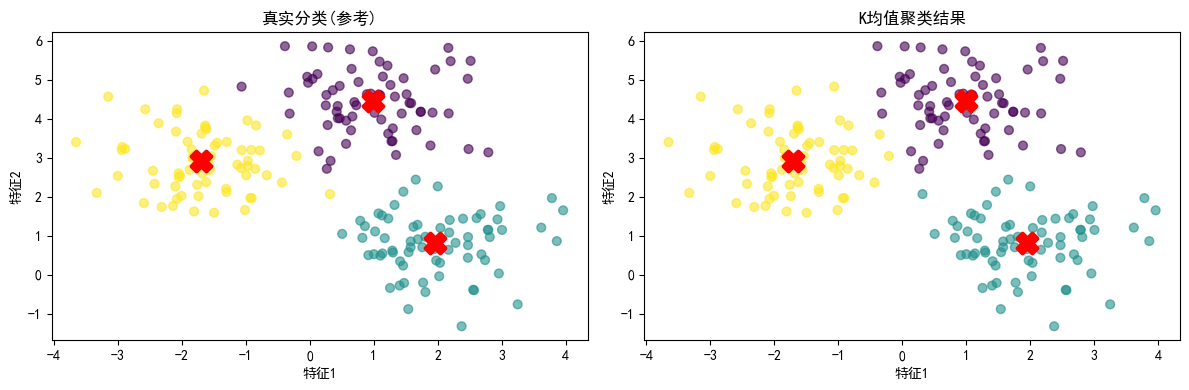

In [4]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1],c=y,s=40,cmap='viridis',alpha=0.6)
plt.scatter(centers[:,0],centers[:,1],c='red',s=200,marker='X',linewidths=3)
plt.title('真实分类(参考)')
plt.xlabel('特征1')
plt.ylabel('特征2')

plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],c=labels,s=40,cmap='viridis',alpha=0.6)
plt.scatter(centers[:,0],centers[:,1],c='red',s=200,marker='X',linewidths=3)
plt.title('K均值聚类结果')
plt.xlabel('特征1')
plt.ylabel('特征2')

plt.tight_layout()
plt.show()

C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


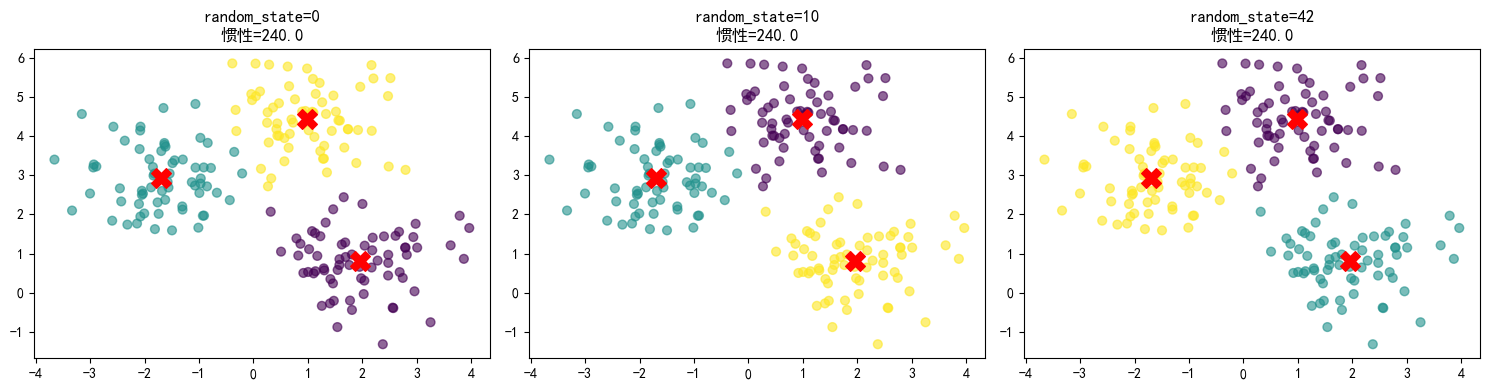

In [11]:
fig,axes = plt.subplots(1,3,figsize=(15,4))

for i,random_state in enumerate([0,10,42]):
    kmeans = KMeans(n_clusters=3,random_state=random_state,n_init=1)
    kmeans.fit(X)

    axes[i].scatter(X[:,0],X[:,1],c=kmeans.labels_,s=40,cmap='viridis',alpha=0.6)
    axes[i].scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],
                    c='red',s=200,marker='X')
    axes[i].set_title(f'random_state={random_state}\n惯性={kmeans.inertia_:.1f}')

plt.tight_layout()
plt.show()

C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


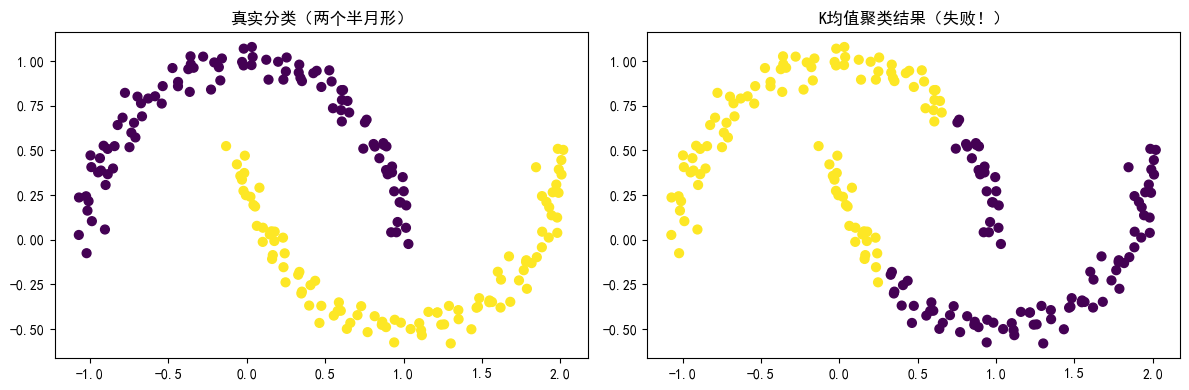

In [13]:
from sklearn.datasets import make_moons


X_moons,y_moons = make_moons(n_samples=200,noise=0.05,random_state=0)

kmeans_moons = KMeans(n_clusters=2,random_state=42)
kmeans_moons.fit(X_moons)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(X_moons[:,0],X_moons[:,1],c=y_moons,s=40,cmap='viridis')
plt.title('真实分类（两个半月形）')

plt.subplot(1,2,2)
plt.scatter(X_moons[:,0],X_moons[:,1],c=kmeans_moons.labels_,s=40,cmap='viridis')
plt.title('K均值聚类结果（失败！）')

plt.tight_layout()
plt.show()

C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chenq\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

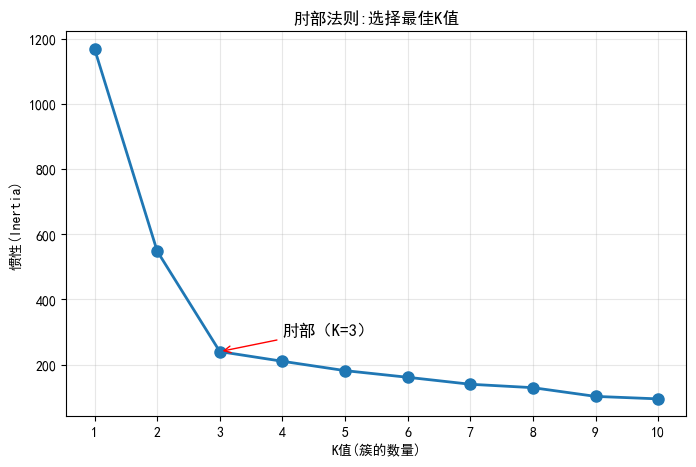

In [15]:
inertias =[]
K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range,inertias,'o-',linewidth=2,markersize=8)
plt.xlabel('K值(簇的数量)')
plt.ylabel('惯性(Inertia)')
plt.title('肘部法则:选择最佳K值')
plt.xticks(K_range)
plt.grid(True,alpha=0.3)

plt.annotate('肘部（K=3）',xy=(3,inertias[2]),xytext=(4,inertias[2]+50),
                 arrowprops=dict(arrowstyle='->',color='red'),fontsize=12)
plt.show()